# A/B Testing - Marketing campaign

A marketing campaign targeting website users was conducted to increase product sales, and for this, an advertisement was specifically developed for this purpose.

To determine whether the campaign succeeded in its goal, specifically, whether the ad actually contributed to driving more sales, website users were randomly assigned to two groups: one group saw the specially designed ad (AD), while the other served as a control group and was shown a generic ad (PSA).

Our objective here is to determine whether the conversion rates of the two groups differ and whether that difference is statistically significant.

## Dataset

The analysis will be conducted using the [Marketing A/B Testing](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing) dataset, which involves an A/B test: "a randomized experiment in which different versions of a variable (such as an advertisement or a system feature) are presented to different groups of users simultaneously. The goal is to evaluate the variable's impact on the final outcome."

In [ ]:
import pandas as pd

df = pd.read_csv('marketing_AB.csv')
print(df.shape)
df.head()

(588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


Initially, the dataset contains the following columns:

- `Unnamed: 0`: numeric index of the dataset rows (numeric)
- `user id`: unique user ID (numeric).
- `test group`: indicates the group the user belongs to—either the group that saw the ad ('ad') or the control group ('psa') (categorical: ad, psa).
- `converted`: indicates whether the user purchased the product (boolean).
- `total ads`: total number of ads viewed by the user (numeric).
- `most ads day`: day of the week when the user viewed the highest number of ads (categorical: Sunday, Monday, Tuesday, Wednesday, Thursday, Friday, Saturday).
- `most ads hour`: hour of the day when the user viewed the highest number of ads (numeric).

# Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


Apparently, we don't need to worry about rows with missing values, so let's start exploring the dataset: checking the data types in each column, their possible values, and whether there are any duplicate rows.

In [ ]:
# change columns label, just because I prefer this way
df.columns      = [c.replace(' ', '_').replace(':', '') for c in df.columns.str.lower()]
df['converted'] = df['converted'].astype(int)
# df.head()

In [ ]:
# check for duplicated rows by index
df.duplicated(subset='unnamed_0').sum()

np.int64(0)

In [ ]:
# check for duplicated users
df.duplicated(subset='user_id').sum()

np.int64(0)

In [ ]:
# check for duplicated rows, removing ID columns
df.drop(columns=['unnamed_0', 'user_id']).duplicated().sum()

np.int64(543623)

Since we have already established that the rows counted above represent different users, we do not need to take any action to clean up duplicate data in the dataset.

We will simply remove the columns that would allow for the identification of the measurements, as there is no need for them:

In [ ]:
df = df.iloc[:,2:] # remove ID columns, there is no point in identify users
df.head()

,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,ad,0,130,Monday,20
1,ad,0,93,Tuesday,22
2,ad,0,21,Tuesday,18
3,ad,0,355,Tuesday,10
4,ad,0,276,Friday,14


## Proportion between groups in the dataset

Next, we will check the proportion in which the groups are distributed across the dataset:

In [ ]:
# check proportion between groups
df['test_group'].value_counts(normalize=True)

,proportion
test_group,
ad,0.96
psa,0.04


We can see that users who saw the specifically designed ad (AD) account for 96% of the dataset, while those who saw the generic ad (PSA) make up only 4%; this indicates an unbalanced experiment.

An unbalanced experiment is not necessarily a bad thing. In fact, this is often intentional, as companies may prefer to expose the majority of the experimental population to the option already known to be safer.

In this case, the safer choice is the ad specifically created for the product (AD), which is expected to drive more sales. Showing the generic ad (PSA) to users can represent an "opportunity cost" for the company; therefore, minimizing this group may make sense from a business perspective.

Another point worth mentioning is that the imbalance does not introduce bias into the analysis. If we consider that we are working with a population of users selected for the experiment:

- randomly
- based on conditions that do not influence the purchasing decision
- under similar seasonal conditions
- without direct interaction between them
- or where a group is small due to a business decision rather than an inherent group characteristic

then we need not worry about the populations exhibiting bias (i.e., being systematically different).

What the imbalance between groups does result in is a **reduction in the overall statistical power of the experiment**, as the smaller group will contribute a proportionately less precise estimate.

## Conversion rate in each group

We proceed by calculating a few more indicators for each of the groups, such as the conversion rate and some aggregations of the total number of ads viewed:

In [ ]:
# make counts according to group and calculate conversion rate
df_groups = (
    df.groupby('test_group').agg(
        n_group=("test_group", "count"),
        conv_qtt=("converted", "sum"),
        min_ads=("total_ads", "min"),
        max_ads=("total_ads", "max"),
        avg_ads=("total_ads", "mean"),
        median_ads=("total_ads", "median")
    ).assign(
        conv_rate=lambda inner_df: inner_df.conv_qtt / inner_df.n_group,
        group_proportion=lambda inner_df: inner_df.n_group / len(df)
    )
)

df_groups

,n_group,conv_qtt,min_ads,max_ads,avg_ads,median_ads,conv_rate,group_proportion
test_group,,,,,,,,
ad,564577,14423,1,2065,24.823365,13.0,0.025547,0.96
psa,23524,420,1,907,24.761138,12.0,0.017854,0.04


In [ ]:
conv_rate_diff = df_groups['conv_rate']['ad'] - df_groups['conv_rate']['psa']
lift           = df_groups['conv_rate']['ad'] / df_groups['conv_rate']['psa']

print(f"Difference observed between the two proportions: {conv_rate_diff:.2%}")
print(f"Lift: {lift:.2f}")

Difference observed between the two proportions: 0.77%
Lift: 1.43


Here, we see that we have indeed calculated different conversion rates for each group, with the specific ad group (AD) showing the highest rate $p_{_{AD}} = 2.55\%$, compared to $p_{_{PSA}} = 1.79\%$ for the group that saw the generic ad (PSA). **Let’s determine whether this $0.77\%$ difference is statistically significant, allowing us to conclude that one ad is more effective than the other.**

Another interesting point we observe is the difference in the number of ads users might see. Let’s see if we can gain further insight by breaking down the groups based on whether or not users purchased the product:

In [ ]:
# check average total amount of Ads, according to group and if it was converted or not
pd.crosstab(df['test_group'], df['converted'], values=df['total_ads'], aggfunc='mean')

converted,0,1
test_group,,
ad,23.274449,83.905567
psa,23.697412,83.276190


Here we see that, on average, users who purchased the product were also exposed to more ads, regardless of the group.



## _"Is there a relationship between the total number of ads and conversion rates?"_

Next, we will delve a little deeper into the "number of ads" viewed; below are the key percentiles:

In [ ]:
# descritive esthatisthics of total_ads
df_total_ads_describe = df['total_ads'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.997]).to_frame().T
df_total_ads_describe

,count,mean,std,min,25%,50%,75%,95%,99.7%,max
total_ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,88.0,338.0,2065.0


In [ ]:
# check correlation between total amount of ads saw and conversion
df[['converted', 'total_ads']].corr()

,converted,total_ads
converted,1.000000,0.217419
total_ads,0.217419,1.000000


Based on the results above, we see a positive correlation between `total_ads` and `converted`, but this correlation is not strong. Furthermore, we can observe that the distribution of `total_ads` is not symmetrical but rather right-skewed.

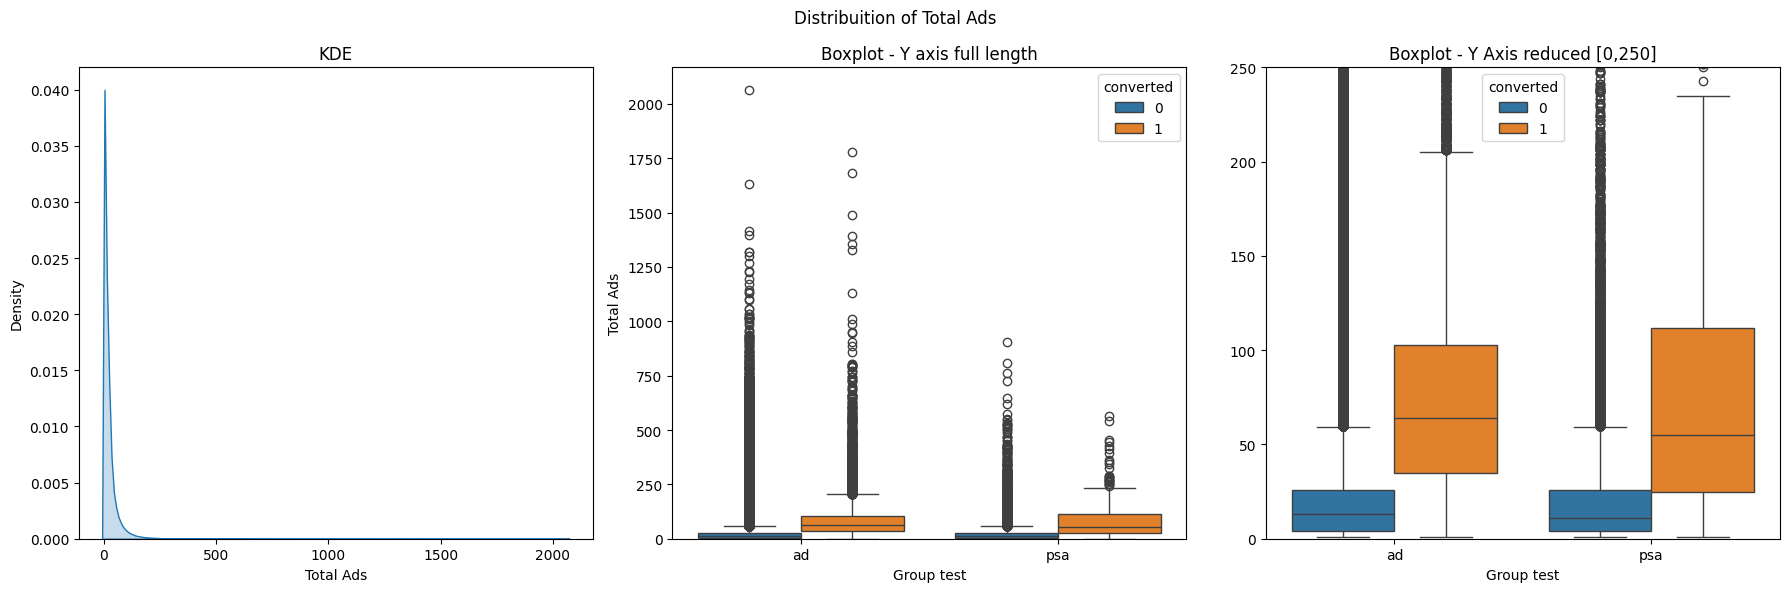

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

sns.kdeplot(data=df, x="total_ads", fill=True, ax=ax1)
ax1.set_title('KDE')
ax1.set_xlabel('Total Ads')
ax1.set_ylabel('Density')

sns.boxplot(data=df, x="test_group", y="total_ads", hue="converted", ax=ax2)
ax2.set_title('Boxplot - Y axis full length')
ax2.set_xlabel('Group test')
ax2.set_ylabel('Total Ads')
ax2.set_ylim(ymin=0)

sns.boxplot(data=df, x="test_group", y="total_ads", hue="converted", ax=ax3)
ax3_lim_sup = 250
ax3.set_title(f"Boxplot - Y Axis reduced [0,{ax3_lim_sup}]")
ax3.set_xlabel('Group test')
ax3.set_ylabel('')
ax3.set_ylim(ymin=0, ymax=ax3_lim_sup)

plt.suptitle("Distribuition of Total Ads")
plt.tight_layout()
plt.show()

### _"Do we need to worry about outliers in our dataset?"_

Since the distribution is not symmetric, we cannot simply apply the Interquartile Method to identify potential outliers, as that method assumes the distance between $\text{Q3}$ and the "natural upper limit" is the same as that between $\text{Q1}$ and the "natural lower limit", a situation that clearly does not apply here.

Nevertheless, let us apply the Interquartile Method to see the result:

In [ ]:
# selecting outliers by interquartile method (IQR)
# calculate quantiles
q1  = df['total_ads'].quantile(0.25)
q3  = df['total_ads'].quantile(0.75)
iqr = q3 - q1

limit_inf = q1 - 1.5 * iqr
limit_sup = q3 + 1.5 * iqr

# select outliers
df_outliers_iqr = df[(df['total_ads'] < limit_inf) | (df['total_ads'] > limit_sup)]

print(f"Total of outliers [IQR]:\t{len(df_outliers_iqr)}")
print(f"Perncentage of outliers [IQR]:\t{(len(df_outliers_iqr) / len(df)):.1%}")

Total of outliers [IQR]:	52057
Perncentage of outliers [IQR]:	8.9%


If we were to apply this method, we would end up identifying as potential outliers various users who simply viewed a large number of ads, a behavior that can be quite common in this type of problem, as users who already intend to purchase the product may be more exposed to ads.

For this problem, a more suitable (and simple) way to identify potential outliers is to use a percentile cutoff, selecting all records with a value exceeding the 99.7th percentile:

In [ ]:
# selecting outliers by quantil cut, all records higher than q(0.997)
lim_997 = df_total_ads_describe['99.7%']['total_ads']
df_outliers_997 = df[df['total_ads'] > lim_997]

print(f"Total of outliers [q(0.997)]:\t\t{len(df_outliers_997)}")
print(f"Perncentage of outliers [q(0.997)]:\t{(len(df_outliers_997) / len(df)):.1%}")

Total of outliers [q(0.997)]:		1762
Perncentage of outliers [q(0.997)]:	0.3%


In [ ]:
# fraction between amount of outliers for both methods
len(df_outliers_iqr) / len(df_outliers_997)

29.544267877412032

Here, we identify far fewer records as possible outliers, specifically, 30 times fewer.

Below, we once again perform a count by group, but this time considering only those identified as possible outliers:

In [ ]:
# make counts according to group and calculate conversion rate, for the selected as outliers
df_outliers_997.groupby('test_group').agg(
    n_group=("test_group", "count"),
    conv_qtt=("converted", "sum"),
    min_ads=("total_ads", "min"),
    max_ads=("total_ads", "max"),
    avg_ads=("total_ads", "mean"),
    median_ads=("total_ads", "median")
).assign(
    conv_rate=lambda inner_df: inner_df.conv_qtt / inner_df.n_group,
    group_proportion=lambda inner_df: inner_df.n_group / len(df_outliers_997)
)

,n_group,conv_qtt,min_ads,max_ads,avg_ads,median_ads,conv_rate,group_proportion
test_group,,,,,,,,
ad,1693,283,339,2065,494.891317,436.0,0.167159,0.96084
psa,69,10,340,907,455.913043,421.0,0.144928,0.03916


Based on the result above, we see that the proportion between the two groups within the "outliers" mirrors that of the original data. Therefore, based on this alone, I will consider that **outliers are not a cause for concern regarding the problem at hand**.

Furthermore, we observe an interesting point: **conversion rates among the "outliers" are significantly higher than the overall rates**, which makes perfect sense. We had previously found indications that those who purchased the product viewed more ads than those who did not; since the "potential outliers" identified here viewed far more ads than the dataset average, this result was, in a way, to be expected.

### _"Como a taxa de conversão evolui de acordo com a quantidade de anúncios?"_

Next, we will delve a bit deeper into the "number of ads viewed" by creating a new variable that categorizes the records. To do this, we will use the [`pd.cut`](https://pandas.pydata.org/docs/reference/api/pandas.cut.html) function.

Instead of simply lumping all the (presumed) "outliers" into a single category, we will define multiple bins to maintain a "certain logic regarding the step sizes" that determine the category boundaries:

In [ ]:
# applies categorization to the amount of total Ads
bins                = [0, 10, 50, 100, 338, 500, 1000, df['total_ads'].max()]
df['total_ads_cat'] = pd.cut(df['total_ads'], bins=bins, right=True)

df_all_conv = df.groupby(['total_ads_cat'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
    avg_ads=("total_ads", "mean"),
    median_ads=("total_ads", "median")
).assign(
    conv_rate=lambda df_i: df_i.conv_qtt / df_i.n_users
)

df_all_conv

,n_users,conv_qtt,avg_ads,median_ads,conv_rate
total_ads_cat,,,,,
"(0, 10]",260775,858,4.204548,4.0,0.003290
"(10, 50]",258260,4844,23.503574,21.0,0.018756
"(50, 100]",46002,5242,69.384896,67.0,0.113952
"(100, 338]",21302,3606,158.180218,139.0,0.169280
"(338, 500]",1177,192,402.316058,394.0,0.163127
"(500, 1000]",549,93,639.675774,609.0,0.169399
"(1000, 2065]",36,8,1238.916667,1159.5,0.222222


Above, we can clearly see that, in general, as the number of ads displayed increases, the conversion rate also increases.

Below, we calculate the overall conversion rates and the rates for each group:

In [ ]:
df_ad_conv = df.query(" test_group == 'ad' ").groupby(['total_ads_cat'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
).assign(
    conv_rate=lambda df: df.conv_qtt / df.n_users
)

df_psa_conv = df.query(" test_group == 'psa' ").groupby(['total_ads_cat'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
).assign(
    conv_rate=lambda df: df.conv_qtt / df.n_users
)

df_conversion_rates = pd.DataFrame({
    'all_conv_rate': df_all_conv['conv_rate'],
    'ad_conv_rate': df_ad_conv['conv_rate'],
    'psa_conv_rate': df_psa_conv['conv_rate'],
    'lift': df_ad_conv['conv_rate'] / df_psa_conv['conv_rate']
})

df_conversion_rates

,all_conv_rate,ad_conv_rate,psa_conv_rate,lift
total_ads_cat,,,,
"(0, 10]",0.003290,0.003259,0.003991,0.816515
"(10, 50]",0.018756,0.018869,0.015770,1.196518
"(50, 100]",0.113952,0.116311,0.057744,2.014240
"(100, 338]",0.169280,0.171701,0.116897,1.468822
"(338, 500]",0.163127,0.163265,0.160000,1.020408
"(500, 1000]",0.169399,0.171698,0.105263,1.631132
"(1000, 2065]",0.222222,0.222222,NaN,NaN


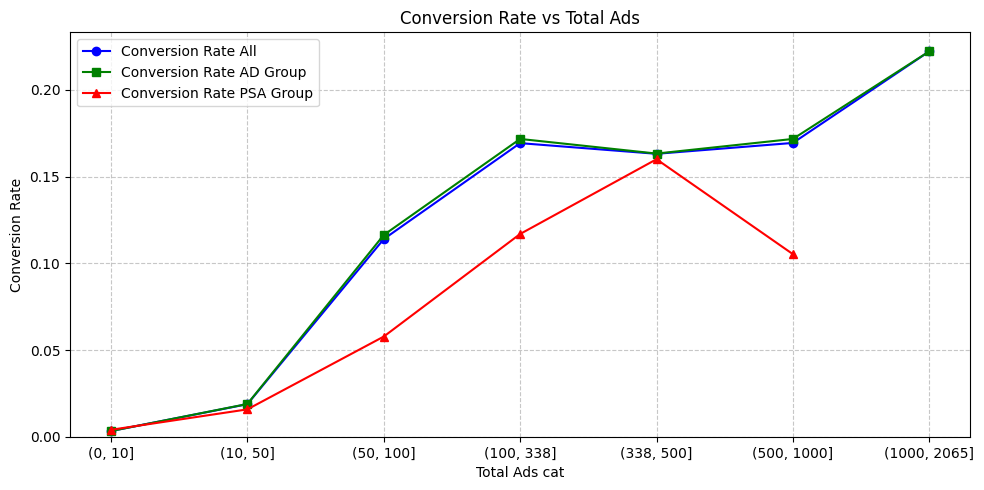

In [ ]:
def plot_lines_for_rate(df_rates: pd.DataFrame, title_complement: str, axis_x_label: str, axis_x_ticks: bool = False) -> None:
    plot_config = [
        ('all_conv_rate', 'o', 'blue',  'All'),
        ('ad_conv_rate',  's', 'green', 'AD Group'),
        ('psa_conv_rate', '^', 'red',   'PSA Group')
    ]

    plt.figure(figsize=(10, 5))
    for col, marker, color, label in plot_config:
        plt.plot(df_rates.index.astype(str), df_rates[col],
            marker=marker, color=color, label=f"Conversion Rate {label}", linestyle='-')

    plt.title(f"Conversion Rate vs {title_complement}")
    plt.xlabel(axis_x_label)
    plt.ylabel('Conversion Rate')
    plt.ylim(ymin=0)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    if axis_x_ticks:
        plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

plot_lines_for_rate(df_conversion_rates, 'Total Ads', 'Total Ads cat')

Note that, with the exception of the first category, the conversion rate for the AD group is higher than that of the PSA group in all other categories.

It is evident that the curves for the overall rate and the AD group practically overlap, which makes perfect sense, given that this group accounts for 96% of the dataset. Furthermore, we can see that, except for the last category of the PSA group, the conversion rate consistently increases with the number of ads.

Although the curve is rising, the conversion rate appears to plateau upon reaching the $(100, 338]$ category. This may indicate that, beyond this point, the number of ads displayed ceases to be a decisive factor in conversion.

#### _"Existe um limiar de visualizações em que a taxa de conversão deixa de crescer?"_

Let's try to identify a point or range where the increase in the conversion rate "slows down." In other words, we want to find a point or range where, even as the number of displayed ads continues to rise, the conversion rate grows more slowly or even stabilizes.

We will redistribute the number of ads into new categories, now ensuring an equal number of data points in each category by using the [`pd.qcut`](https://pandas.pydata.org/docs/reference/api/pandas.qcut.html) function:

(36, 5)
                 n_users  conv_qtt     avg_ads  median_ads  conv_rate
total_ads_cat_                                                       
(0.999, 2.0]       96433       183    1.413002         1.0   0.001898
(2.0, 3.0]         28661        81    3.000000         3.0   0.002826
(3.0, 4.0]         23426        84    4.000000         4.0   0.003586
(4.0, 5.0]         29303       101    5.000000         5.0   0.003447
(5.0, 6.0]         23409        74    6.000000         6.0   0.003161
(57.0, 66.0]       11109      1095   61.779548        62.0   0.098569
(66.0, 79.0]       11640      1457   72.543127        72.0   0.125172
(79.0, 99.0]       11228      1706   88.636890        88.0   0.151942
(99.0, 143.0]      11741      2098  118.049144       116.0   0.178690
(143.0, 2065.0]    11728      1881  246.704383       202.0   0.160385


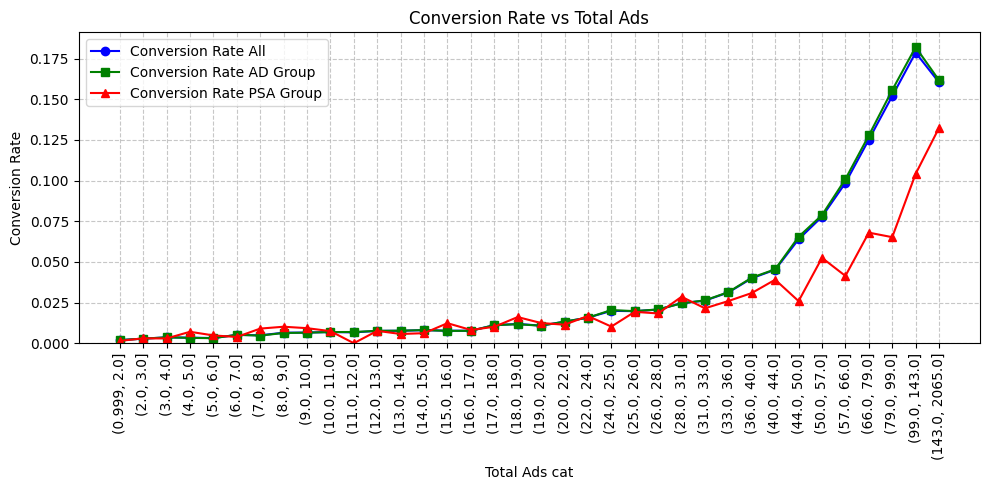

In [ ]:
df['total_ads_cat_'] = pd.qcut(df['total_ads'], q=50, duplicates='drop')

df_all_conv_ = df.groupby(['total_ads_cat_'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
    avg_ads=("total_ads", "mean"),
    median_ads=("total_ads", "median")
).assign(
    conv_rate=lambda df_i: df_i.conv_qtt / df_i.n_users
)

print(df_all_conv_.shape)
print(pd.concat([df_all_conv_.head(), df_all_conv_.tail()]))


df_ad_conv_ = df.query(" test_group == 'ad' ").groupby(['total_ads_cat_'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
).assign(
    conv_rate=lambda df: df.conv_qtt / df.n_users
)

df_psa_conv_ = df.query(" test_group == 'psa' ").groupby(['total_ads_cat_'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
).assign(
    conv_rate=lambda df: df.conv_qtt / df.n_users
)

df_conversion_rates_ = pd.DataFrame({
    'all_conv_rate': df_all_conv_['conv_rate'],
    'ad_conv_rate': df_ad_conv_['conv_rate'],
    'psa_conv_rate': df_psa_conv_['conv_rate'],
    'lift': df_ad_conv_['conv_rate'] / df_psa_conv_['conv_rate']
})

plot_lines_for_rate(df_conversion_rates_, 'Total Ads', 'Total Ads cat', True)

We observed above that the number of bins resulting from the classification was 36, which is fewer than the 50 specified for the `qcut` function. This occurs because we are attempting to classify a distribution containing values ​​that repeat frequently, while `qcut` splits the data by trying to place an equal number of elements into each interval.

Consider, for example, `total_ads == 1`: note that it appears in over fifty thousand rows, while `total_ads == 2` appears in nearly forty thousand rows. Since certain numbers appear so frequently, when the intervals are created to allocate an equal number of elements to each, the boundaries of some intervals may coincide. Consequently, the resulting number of bins is lower than the number originally specified.

In [ ]:
# some examples of values ​​that repeat frequently
df.total_ads.value_counts().head()

,count
total_ads,
1,56606
2,39827
5,29303
3,28661
4,23426


To identify the point where the growth of the conversion rate slows down, we will use the [`kneed.KneeLocator`](https://kneed.readthedocs.io/en/stable/) function, which allows us to find inflection points on curves. We begin by applying it to the classification with 7 bins, and then to the one with 50 (36) bins:

Ponto de cotovelo detectado (q=7): (100, 338] (219.0)
Ponto de cotovelo detectado (q=36): (99.0, 143.0] (121.0)


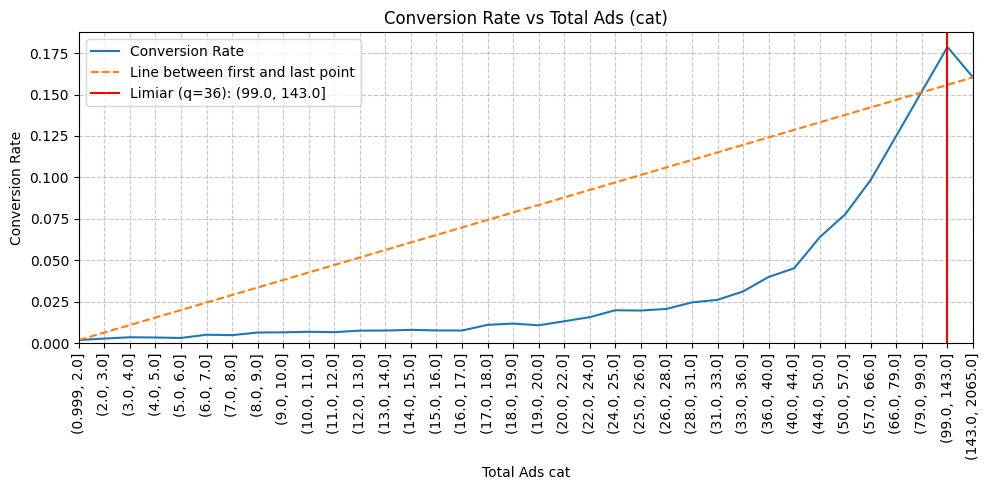

In [ ]:
# !pip install kneed
from kneed import KneeLocator

kl_q7 = KneeLocator(x=[i.mid for i in df_all_conv.index], y=df_all_conv['conv_rate'], curve='concave', direction='increasing')
knee_interval = str([i for i in df_all_conv.index if kl_q7.knee in i][0])
print(f"Knee point detected (q=7): {knee_interval} ({kl_q7.knee})")
kl_q36        = KneeLocator(x=[i.mid for i in df_all_conv_.index], y=df_all_conv_['conv_rate'], curve='concave', direction='increasing')
knee_interval = str([i for i in df_all_conv_.index if kl_q36.knee in i][0])
print(f"Knee point detected (q=36): {knee_interval} ({kl_q36.knee})")

def plot_lines_for_rate_with_knee(df_rates: pd.DataFrame,
                                  num_bins: str) -> None:
    plt.figure(figsize=(10, 5))

    # plot conversion rate over categories
    plt.plot(df_rates.index.astype(str), df_rates['conv_rate'], label='Conversion Rate')
    # plt.plot([i.mid for i in df_rates.index], df_rates['conv_rate'], label='Conversion Rate')

    # plot line connecting first and last point
    plt.plot([str(df_rates.index[0]), str(df_rates.index[-1])],
            [df_rates['conv_rate'].iloc[0], df_rates['conv_rate'].iloc[-1]],
            label='Line between first and last point', linestyle='--')

    # plot vertical line
    plt.axvline(x=knee_interval, color='red', label=f"Limiar (q={num_bins}): {knee_interval}")

    plt.title(f"Conversion Rate vs Total Ads (cat)")
    plt.ylabel('Conversion Rate')
    plt.ylim(ymin=0)
    plt.xlabel('Total Ads cat')
    plt.xticks(rotation=90)
    plt.xlim(xmin=str(df_rates.index[0]), xmax=str(df_rates.index[-1]))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_lines_for_rate_with_knee(df_all_conv_, '36')

However, note that the threshold for the number of ads changes depending on the number of bins into which the points were distributed. This happens for two reasons:

- when we have **fewer bins**, we lose some resolution; while we gain precision because there are more points per bin, the resulting curve is coarser, making it harder to identify the true threshold;
- and when we have **more bins**, we gain some curve resolution, but, since there are fewer points per bin, we also end up with more noise.

Let's run it with two more values of `q`, just to see the results:

In [ ]:
df['total_ads_cat_'] = pd.qcut(df['total_ads'], q=200, duplicates='drop')

df_all_conv_ = df.groupby(['total_ads_cat_'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
    avg_ads=("total_ads", "mean"),
    median_ads=("total_ads", "median")
).assign(
    conv_rate=lambda df_i: df_i.conv_qtt / df_i.n_users
)

print(df_all_conv_.shape)
print(pd.concat([df_all_conv_.head(), df_all_conv_.tail()]))
kl_q200        = KneeLocator(x=[i.mid for i in df_all_conv_.index], y=df_all_conv_['conv_rate'], curve='concave', direction='increasing')
knee_interval = str([i for i in df_all_conv_.index if kl_q200.knee in i][0])
print(f"\nKnee point detected (q=200): {knee_interval} ({kl_q200.knee})")

(71, 5)
                 n_users  conv_qtt     avg_ads  median_ads  conv_rate
total_ads_cat_                                                       
(0.999, 2.0]       96433       183    1.413002         1.0   0.001898
(2.0, 3.0]         28661        81    3.000000         3.0   0.002826
(3.0, 4.0]         23426        84    4.000000         4.0   0.003586
(4.0, 5.0]         29303       101    5.000000         5.0   0.003447
(5.0, 6.0]         23409        74    6.000000         6.0   0.003161
(128.0, 143.0]      2826       514  135.508493       135.0   0.181883
(143.0, 165.0]      2915       502  153.926244       154.0   0.172213
(165.0, 202.0]      3003       470  182.423909       181.0   0.156510
(202.0, 276.0]      2882       449  233.219292       231.0   0.155795
(276.0, 2065.0]     2928       460  418.270833       362.5   0.157104

Ponto de cotovelo detectado (q=200): (30.0, 31.0] (30.5)


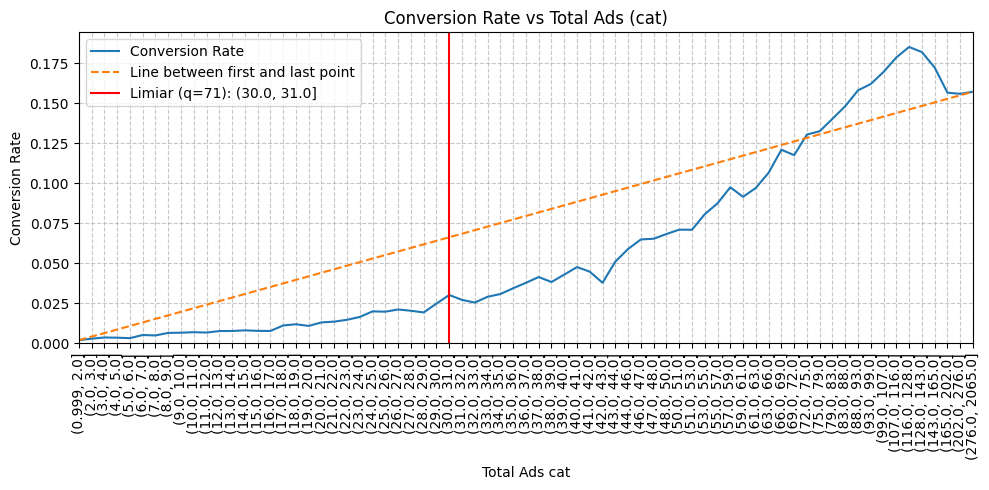

In [ ]:
plot_lines_for_rate_with_knee(df_all_conv_, '71')

(96, 5)
                 n_users  conv_qtt     avg_ads  median_ads  conv_rate
total_ads_cat_                                                       
(0.999, 2.0]       96433       183    1.413002         1.0   0.001898
(2.0, 3.0]         28661        81    3.000000         3.0   0.002826
(3.0, 4.0]         23426        84    4.000000         4.0   0.003586
(4.0, 5.0]         29303       101    5.000000         5.0   0.003447
(5.0, 6.0]         23409        74    6.000000         6.0   0.003161
(181.0, 202.0]      1487       231  191.756557       191.0   0.155346
(202.0, 230.0]      1429       230  215.488453       215.0   0.160952
(230.0, 276.0]      1453       219  250.657261       249.0   0.150723
(276.0, 362.0]      1464       226  314.006831       312.0   0.154372
(362.0, 2065.0]     1464       234  522.534836       466.0   0.159836

Knee point detected (q=400): (26.0, 27.0]


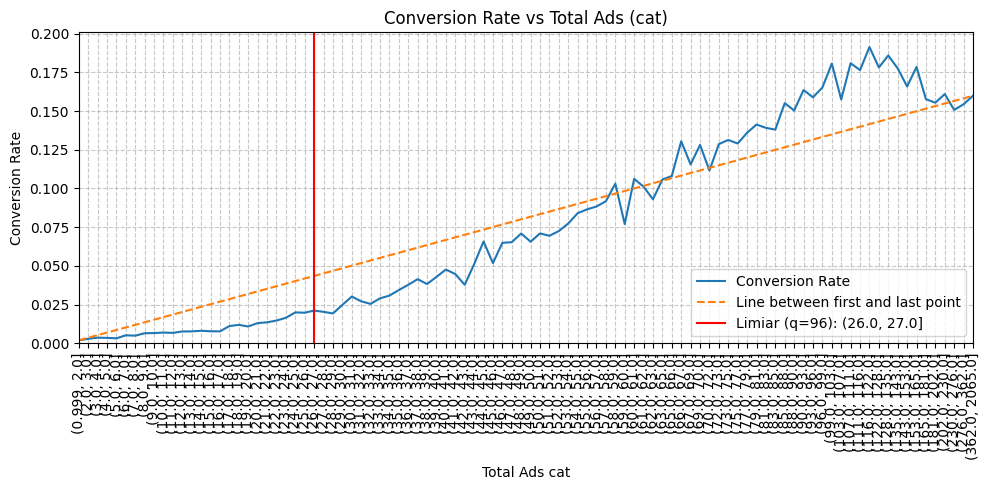

In [ ]:
df['total_ads_cat_'] = pd.qcut(df['total_ads'], q=400, duplicates='drop')

df_all_conv_ = df.groupby(['total_ads_cat_'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
    avg_ads=("total_ads", "mean"),
    median_ads=("total_ads", "median")
).assign(
    conv_rate=lambda df_i: df_i.conv_qtt / df_i.n_users
)

print(df_all_conv_.shape)
print(pd.concat([df_all_conv_.head(), df_all_conv_.tail()]))
kl_q400        = KneeLocator(x=[i.mid for i in df_all_conv_.index], y=df_all_conv_['conv_rate'], curve='concave', direction='increasing')
knee_interval = str([i for i in df_all_conv_.index if kl_q400.knee in i][0])
print(f'\nKnee point detected (q=400): {knee_interval}')


plot_lines_for_rate_with_knee(df_all_conv_, '96')

In cases where the threshold depends on the `q` used for classification, we can calculate the threshold for different values of `q` and find the median or a range of thresholds:

In [ ]:
import json

results = {}
for q in [10, 25, 50, 100, 150, 200, 300, 400]:
    df['total_ads_cat_'] = pd.qcut(df['total_ads'], q=q, duplicates='drop')
    df_all_conv_ = df.groupby(['total_ads_cat_'], observed=False).agg(
        n_users=("test_group", "count"),
        conv_qtt=("converted", "sum")
    ).assign(
        conv_rate=lambda df_i: df_i.conv_qtt / df_i.n_users
    )

    kl = KneeLocator(x=[i.mid for i in df_all_conv_.index], y=df_all_conv_['conv_rate'],
                      curve='concave', direction='increasing')
    results[df_all_conv_.shape[0]] = kl.knee

print(json.dumps(results, sort_keys=True, indent=4))
print(f"Median: {pd.Series(results).median()}")
print(f"Limiar interval: [{min(results.values())}, {max(results.values())}]")

{
    "10": 45.0,
    "22": 82.5,
    "36": 121.0,
    "51": 30.5,
    "62": 30.5,
    "71": 30.5,
    "85": 30.5,
    "96": 26.5
}
Median: 30.5
Limiar interval: [26.5, 121.0]


Based on the result above, we can state that the threshold for the total number of ads, beyond which we begin to observe marginal gains in the conversion rate, falls within the range of $[27, 121]$, with a median of $31$, depending on the granularity used.

This implies that, beyond this point, the increase in conversion rate may not be significant enough to justify the higher investment required to show more ads to users.

## _"How does the conversion rate behave based on the day of the week with the highest number of ad views?"_

In [ ]:
df['most_ads_day'].unique()

array(['Monday', 'Tuesday', 'Friday', 'Saturday', 'Wednesday', 'Sunday',
       'Thursday'], dtype=object)

In [ ]:
# frequency count of days with most ads saw
df_most_ads_day = pd.DataFrame({
    'num_records': df['most_ads_day'].value_counts(),
    'proportion': df['most_ads_day'].value_counts(normalize=True)
})

lower_ads_day                        = df_most_ads_day.sort_values(by="proportion", ascending=True)['num_records'].iloc[0]
df_most_ads_day['num_records_level'] = df_most_ads_day['num_records'] - lower_ads_day

# general convertion rate by day
df_all_conv_by_day = df.groupby(['most_ads_day'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum")
).assign(
    conv_rate=lambda df_i: df_i.conv_qtt / df_i.n_users
)

# convertion rate for AD by day
df_ad_conv_by_day = df.query(" test_group == 'ad' ").groupby(['most_ads_day'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
).assign(
    conv_rate=lambda df: df.conv_qtt / df.n_users
)

# convertion rate for PSA by day
df_psa_conv_by_day = df.query(" test_group == 'psa' ").groupby(['most_ads_day'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
).assign(
    conv_rate=lambda df: df.conv_qtt / df.n_users
)

df_conversion_rates_by_day = (
    df_most_ads_day.merge(pd.DataFrame({
        'all_conv_rate': df_all_conv_by_day['conv_rate'],
        'ad_conv_rate': df_ad_conv_by_day['conv_rate'],
        'psa_conv_rate': df_psa_conv_by_day['conv_rate'],
        'lift': df_ad_conv_by_day['conv_rate'] / df_psa_conv_by_day['conv_rate']
    }), left_index=True, right_index=True)
    .reindex(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
)

df_conversion_rates_by_day

,num_records,proportion,num_records_level,all_conv_rate,ad_conv_rate,psa_conv_rate,lift
most_ads_day,,,,,,,
Sunday,85391,0.145198,7912,0.024476,0.024620,0.020595,1.195430
Monday,87073,0.148058,9594,0.032812,0.033241,0.022559,1.473553
Tuesday,77479,0.131744,0,0.029840,0.030440,0.014448,2.106909
Wednesday,80908,0.137575,3429,0.024942,0.025356,0.015759,1.608945
Thursday,82982,0.141102,5503,0.021571,0.021637,0.020230,1.069532
Friday,92608,0.157470,15129,0.022212,0.022465,0.016303,1.377971
Saturday,81660,0.138854,4181,0.021051,0.021307,0.013996,1.522354


In [ ]:
import numpy as np

# standard deviation for proportion of days, looks well distribuited
np.std(df_conversion_rates_by_day['proportion'])

0.007714116805184034

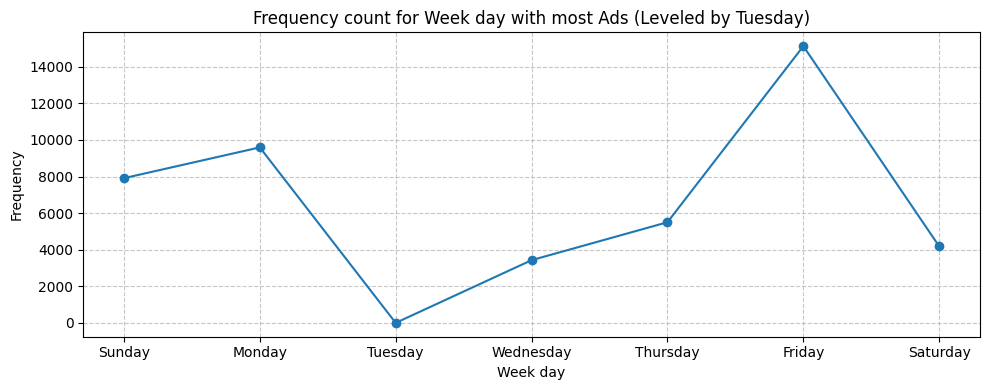

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_conversion_rates_by_day.index, df_conversion_rates_by_day['num_records_level'], marker='o')

plt.title('Frequency count for Week day with most Ads (Leveled by Tuesday)')
plt.xlabel('Week day')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

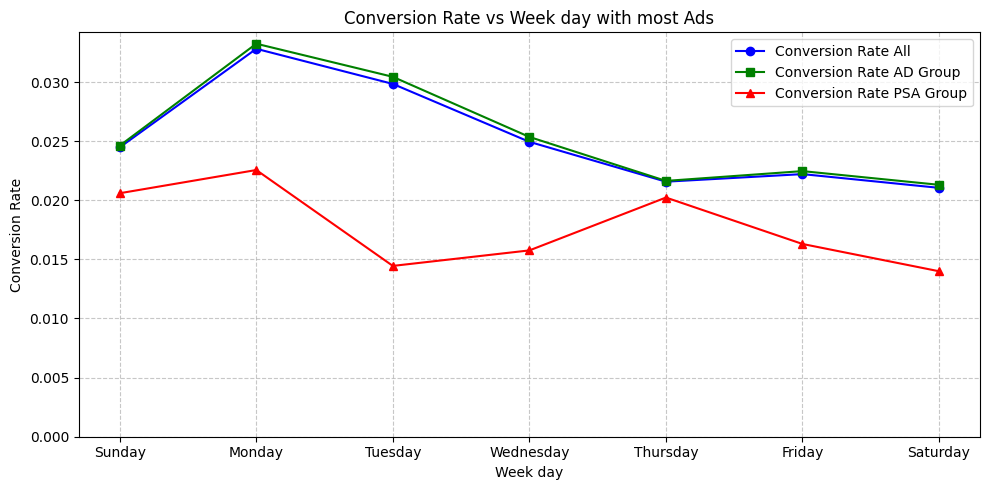

In [ ]:
plot_lines_for_rate(df_conversion_rates_by_day, 'Week day with most Ads', 'Week day')

We observe that the conversion rate varies depending on the day with the highest volume of ad views. Key highlights include:

- Monday: showed the highest rates across the three observed categories: $p_{_{ALL}} = 3.28\%$, $p_{_{AD}} = 3.33\%$, and $p_{_{PSA}} = 2.26\%$.
- Tuesday: yielded the second-lowest rate for the group exposed to generic ads (PSA), $p_{_{PSA}} = 1.44\%$, resulting in the largest lift between the two groups, at a value of $2.1$.
- Saturday: showed the lowest rates across the three observed categories: $p_{_{ALL}} = 2.11\%$, $p_{_{AD}} = 2.13\%$, and $p_{_{PSA}} = 1.40\%$.

## _"How does the conversion rate behave throughout the day, based on the time when the most ads were viewed?"_

In [ ]:
# frequency count of days with most ads saw
df_most_ads_hour = pd.DataFrame({
    'num_records': df['most_ads_hour'].value_counts(),
    'proportion': df['most_ads_hour'].value_counts(normalize=True)
})

df_conv_by_hour = []
for c in [" test_group in ('ad', 'psa') ", " test_group == 'ad' ", " test_group == 'psa' "]:
    df_conv_by_hour.append(
        df.query(f" {c} ").groupby(['most_ads_hour'], observed=False).agg(
            n_users=("test_group", "count"),
            conv_qtt=("converted", "sum"),
        ).assign(
            conv_rate=lambda df_i: df_i.conv_qtt / df_i.n_users
        )
    )

df_conversion_rates_by_hour         = pd.DataFrame(data=[df_i['conv_rate'] for df_i in df_conv_by_hour]).T
df_conversion_rates_by_hour.columns = ['all_conv_rate', 'ad_conv_rate', 'psa_conv_rate']
df_conversion_rates_by_hour         = df_conversion_rates_by_hour.merge(df_most_ads_hour, left_index=True, right_index=True)
df_conversion_rates_by_hour['lift'] = df_conversion_rates_by_hour['ad_conv_rate'] / df_conversion_rates_by_hour['psa_conv_rate']

df_conversion_rates_by_hour

,all_conv_rate,ad_conv_rate,psa_conv_rate,num_records,proportion,lift
most_ads_hour,,,,,,
0,0.018425,0.019213,0.000000,5536,0.009413,inf
1,0.012911,0.013434,0.000000,4802,0.008165,inf
2,0.007313,0.007570,0.000000,5333,0.009068,inf
3,0.010452,0.010425,0.011236,2679,0.004555,0.927799
4,0.015235,0.015850,0.000000,722,0.001228,inf
5,0.020915,0.021563,0.000000,765,0.001301,inf
6,0.022244,0.023174,0.000000,2068,0.003516,inf
7,0.018111,0.018482,0.008439,6405,0.010891,2.190175
8,0.019516,0.019861,0.010622,17627,0.029973,1.869763


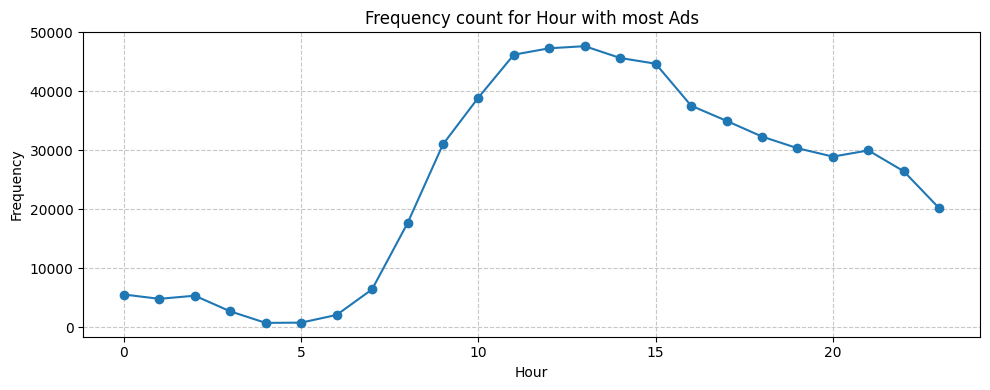

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df_conversion_rates_by_hour.index, df_conversion_rates_by_hour['num_records'], marker='o')

plt.title('Frequency count for Hour with most Ads')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The graph above is quite intuitive and shows the volume of ad views for each hour. Note that the fewest ads are viewed during the early morning hours. This figure rises throughout the morning, peaking at 1:00 PM. From that point on, the number of ad views begins to decline again over time.

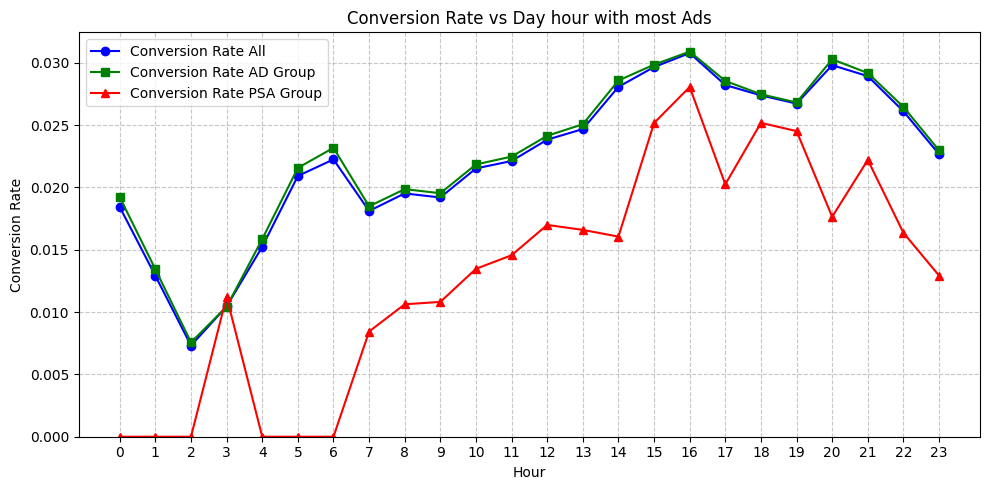

In [ ]:
plot_lines_for_rate(df_conversion_rates_by_hour, 'Day hour with most Ads', 'Hour')

When examining conversion rates across the hours of the day, we observe variations linked to the times when the highest number of ads were viewed. Key highlights include:

- The late afternoon to early evening window yields the highest conversion rates, including the highest peaks, which occur at 4:00 PM ($p_{_{ALL}} = 3.08\%$) and 8:00 PM ($p_{_{ALL}} = 2.98\%$).
- The early morning hours show the poorest results, with a low point at 2:00 AM ($p_{_{ALL}} = 0.73\%$).

# Statistical tests

## Two-proportion $z$-test

Now it is time to perform the statistical test to determine whether there is a significant difference between the two groups, and thus establish whether the specifically developed ad (AD) is more effective than the generic one (PSA).

We begin by setting up the hypotheses:

$$
\left\{
\begin{array}{ll}
H_0: p_{_{AD}} - p_{_{PSA}} = 0 \\\\
H_1: p_{_{AD}} - p_{_{PSA}} > 0
\end{array}
\right.
$$

The null hypothesis states that "the two proportions are equal"—meaning their difference is zero. Since we want to determine if the specific ad (AD) is more effective than the generic one (PSA), the alternative hypothesis must indicate that the proportion for AD is greater than that for PSA; in other words, the difference between the two proportions must be greater than zero.

As we have two independent groups and a large dataset, and wish to compare proportions based on counts, we will use the **two-proportion z-test** via the `proportions_ztest` function from the [statsmodels](https://www.statsmodels.org/devel/generated/statsmodels.stats.proportion.proportions_ztest.html) library. This function takes the following parameters:

- `count`: the number of successes in `nobs` observations for each group.
- `nobs`: the number of trials or observations in each group. This must correspond to the `count` parameter.
- `alternative`: indicates the type of alternative hypothesis; options include 'two-sided' (p1 != p2), 'smaller' (p1 < p2), and 'larger' (p1 > p2). Therefore, in our case, we should use `alternative='larger'`.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(count=[df_ad_conv['conv_qtt'].sum(), df_psa_conv['conv_qtt'].sum()],
                                    nobs=[df_ad_conv['n_users'].sum(), df_psa_conv['n_users'].sum()],
                                    # value=0, # default value for this parameter
                                    alternative='larger')

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 7.3701
P-value: 0.0000


In [ ]:
p_value

np.float64(8.526403580779863e-14)

In [ ]:
significance = 0.05 # 5%
confidence     = 1 - significance
print(f"Confidence level: {confidence:.0%}")

Confidence level: 95%


By setting the significance level at $5\%$, I am stating that: "by pure chance, even if $H_0$ is true, I accept that I will erroneously reject it $5\%$ of the time." Meanwhile, the $p$-value tells me "how extreme the observed result is."

So, if I find a $p$-value $< 5\%$, it means there is **less** than $5\%$ "room" left for values ​​more extreme than the one observed; therefore, I conclude that **I have evidence to reject $H_0$**.

Since we found a $p$-value of $8.5 \times 10^{-14}$, we reject the null hypothesis and can state that **the specific ad (AD) is more effective than the generic one (PSA)**.

In [ ]:
# run the test with other alternative hipothesis
z_stat, p_value = proportions_ztest(count=[df_ad_conv['conv_qtt'].sum(), df_psa_conv['conv_qtt'].sum()],
                                    nobs=[df_ad_conv['n_users'].sum(), df_psa_conv['n_users'].sum()],
                                    alternative='smaller')

print(f"P-value: {p_value:.4f}")

P-value: 1.0000


## 22
Confidence interval

We can also determine the confidence interval for the possible values ​​of the difference between the proportions of the two groups.

To do this, we will use another function from the [statsmodels](https://www.statsmodels.org/devel/generated/statsmodels.stats.proportion.confint_proportions_2indep.html) library, specifically `confint_proportions_2indep`, which has the following parameters:

- `count1` and `nobs1`: number of successes and number of observations for group 1.
- `count2` and `nobs2`: number of successes and number of observations for group 2.
- `compare`: indicates how the two proportions will be compared across the groups. In our case, it is the difference, so we can use the default value, 'diff'.
- `method`: the statistical method used to compute the confidence interval. For `compare='diff'`, options include 'newcomb' (default), 'wald', 'agresti-caffo', and 'score'.
- `alpha`: significance level; the default value is 0.05.

In [ ]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci = confint_proportions_2indep(
    count1=df_ad_conv['conv_qtt'].sum(),
    nobs1=df_ad_conv['n_users'].sum(),
    count2=df_psa_conv['conv_qtt'].sum(),
    nobs2=df_psa_conv['n_users'].sum(),
    alpha=significance
)

print(f'Confidence interval for difference in proportions (95% Confidence level): [{ci[0]:.2%}, {ci[1]:.2%}]')
print(f'Conversion Rate difference observed: {conv_rate_diff:.2%}')

Confidence interval for difference in proportions (95% Confidence level): [0.59%, 0.94%]
Conversion Rate difference observed: 0.77%


In [ ]:
# testing different way to compare proportions
ci = confint_proportions_2indep(
    count1=df_ad_conv['conv_qtt'].sum(),
    nobs1=df_ad_conv['n_users'].sum(),
    count2=df_psa_conv['conv_qtt'].sum(),
    nobs2=df_psa_conv['n_users'].sum(),
    compare='ratio',
    alpha=significance
)

print(f'Confidence interval for lift of proportions (95% Confidence level): [{ci[0]:.2f}, {ci[1]:.2f}]')
print(f'Lift observed: {lift:.2f}')

Confidence interval for lift of proportions (95% Confidence level): [1.30, 1.57]
Lift observed: 1.43


# Summary of results

- Just over 588,000 users were analyzed and divided into two groups: one exposed to an ad specifically designed to sell a product (AD) and another serving as a control, exposed to a generic ad (PSA).
- It was observed that users exposed to the specific ad (AD) had a conversion rate 43% higher than those in the control group (PSA): $p_{_{AD}} = 2.55\%$ versus $p_{_{PSA}} = 1.79\%$.
- Testing confirmed that this difference in conversion rates is statistically significant, meaning it is not merely statistical noise.
- We observed that the conversion rate increases alongside the number of ads viewed by users, reaching nearly $17\%$ when users are exposed to more than 100 ads.
- It was determined that the days of the week with the highest conversion rates are Monday and Tuesday, and the optimal time window for displaying ads is between 2:00 PM and 9:00 PM.